In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import auc, roc_curve

In [2]:
class LogisticRegression(object):
    def __init__(self, X_train, y_train, X_test, y_test, 
                 learn_rate=0.001, n_iters=500, reg_param=0.0):
        # Add bias term (intercept column)
        if X_train.ndim == 1:
            self.X_train = np.hstack((np.array([1]), X_train))
        else:
            self.X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))

        if X_test.ndim == 1:
            self.X_test = np.hstack((np.array([1]), X_test))
        else:
            self.X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
        self.y_train = y_train
        self.y_test = y_test
        
        self.learn_rate = learn_rate
        self.n_iters = n_iters
        
        self.reg_param = reg_param    
        
        # Initialize model weights
        self.weight = np.zeros(self.X_train.shape[1])

        self.accuracy_train = []  # To keep track of accuracy on the training data during gradient ascent process
        self.accuracy_test = []  # To keep track of accuracy on the test data during gradient ascent process

        self.log_likelihood_train = []  # To keep track of average log likelihood on the training data during gradient ascent process
        self.log_likelihood_test = []  # To keep track of average log likelihood on the test data during gradient ascent process
    
    def predict(self, samples, threshold=0.5):
        return self.predict_prob(samples) >= threshold
     
    def predict_prob(self, samples):
        # Todo: Compute and return the predicted probability of each sample having an income >= 50K
        if samples.shape[1] == self.X_train.shape[1] - 1:
            samples = np.c_[np.ones(samples.shape[0]), samples]
        
        return 1 / (1 + np.exp(-samples @ self.weight))

    def compute_gradient(self):
        # Todo: compute and return gradient of the average log likelihood on the training set
        y_pred = self.predict_prob(self.X_train)
        grad = np.dot(self.X_train.T, self.y_train - y_pred) / len(self.y_train)
        
        if self.reg_param > 0:
            grad[1:] -= self.reg_param * self.weight[1:]
            
        return grad

    def gradient_ascent(self):
        # Todo: Run gradient ascent to learn model weights
        # Todo: Store the average log likelihood and the prediction accuracy 
        #       on the training and test sets after every gradient ascent iteration 
        
        for i in np.arange(self.n_iters):
            grads = self.compute_gradient()
            
            self.weight = self.weight + (self.learn_rate * grads)
            
            train_probs = self.predict_prob(self.X_train)
            test_probs = self.predict_prob(self.X_test)

            predictions_train = train_probs >= 0.5
            predictions_test = test_probs >= 0.5

            y_train = self.y_train
            y0_train = 1 - y_train

            y_test = self.y_test
            y0_test = 1 - y_test
            
            ave_logL_train = np.mean(np.log((y_train * train_probs) + (y0_train * (1 - train_probs))))
            ave_logL_test = np.mean(np.log((y_test * test_probs) + (y0_test * (1 - test_probs))))
            
            prediction_accuracy_train = np.mean(predictions_train == self.y_train)
            prediction_accuracy_test = np.mean(predictions_test == self.y_test)

            self.log_likelihood_train += [ave_logL_train]
            self.log_likelihood_test += [ave_logL_test]
    
            self.accuracy_train += [prediction_accuracy_train]
            self.accuracy_test += [prediction_accuracy_test]
        


In [3]:
def preprocess_data(X_train, X_test):
    # Todo: encode categorical features using OneHotEncoder
    # Todo: standardize numerical features using StandardScaler()
    # Todo: return processed training and test sets
    categorical_cols = X_train.select_dtypes(include=['object']).columns
    numerical_cols = X_train.select_dtypes(exclude=['object']).columns

    encoder = OneHotEncoder(drop='first', sparse_output=False)  
    X_train_cat = encoder.fit_transform(X_train[categorical_cols])
    X_test_cat = encoder.transform(X_test[categorical_cols])

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[numerical_cols])
    X_test_num = scaler.transform(X_test[numerical_cols])


    X_train_processed = np.hstack((X_train_num, X_train_cat))
    X_test_processed = np.hstack((X_test_num, X_test_cat))

    return X_train_processed, X_test_processed

In [4]:
def plot_log_likelihood_performance(log_likelihood_train, log_likelihood_test):
    # Todo: plot the average log likelihood curves of the training and test sets
    #      during training process
    plt.plot(log_likelihood_train, label='Training Set')
    plt.plot(log_likelihood_test,  label='Testing Set')
    plt.title('Training Performance')
    plt.xlabel('Iterations')
    plt.ylabel('Average log-likelihood')
    
    plt.legend()
    plt.show()

In [5]:
def plot_accuracy_performance(accuracy_train, accuracy_test):
    # Todo: plot the prediction accuracy curves of the training and test sets
    #      during the training process
    plt.plot(accuracy_train, label='Train Accuracy')
    plt.plot(accuracy_test, label='Test Accuracy')
    plt.xlabel('Iteration')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Performance During Training')
    
    plt.legend()
    plt.show()

In [6]:
def plot_roc(X_train, y_train, X_test , y_test, learner):
    # Todo: plot the ROC curves 
    y_train_prob = learner.predict_prob(X_train)
    y_test_prob = learner.predict_prob(X_test)
    
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    auc_train = auc(fpr_train, tpr_train)

    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
    auc_test = auc(fpr_test, tpr_test)

    plt.figure(figsize=(8, 8))
    plt.plot(fpr_train, tpr_train, label=f'Training Set (AUC = {auc_train:.2f})')
    plt.plot(fpr_test, tpr_test, label=f'Testing Set (AUC = {auc_test:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='green', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.show()

In [7]:
# Load data
train_data = pd.read_csv('cleaned_train_data.csv')
test_data = pd.read_csv('cleaned_test_data.csv')
X_train = train_data.drop(['income'], axis=1, inplace=False)
y_train = train_data['income']
X_test = test_data.drop(['income'], axis=1, inplace=False)
y_test = test_data['income']

In [8]:
# Preprocessing data
processed_X_train, processed_X_test = preprocess_data(X_train, X_test)

In [9]:
# Run gradient ascent with Logistic Regression
learner = LogisticRegression(processed_X_train, y_train.values, processed_X_test, y_test.values,
                                 n_iters=250, learn_rate=0.75)
learner.gradient_ascent()

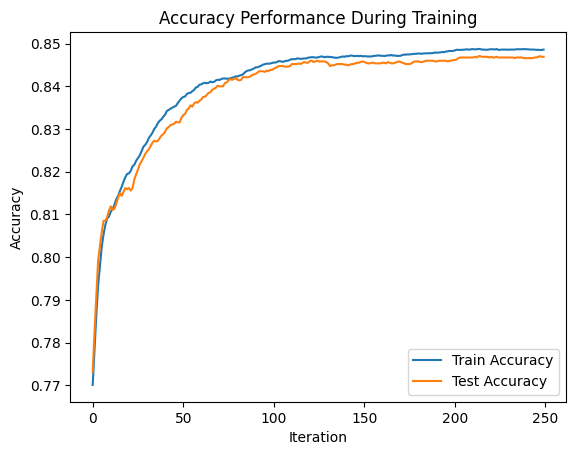

In [10]:
# Plot prediction accuracy during training process
plot_accuracy_performance(learner.accuracy_train, learner.accuracy_test)

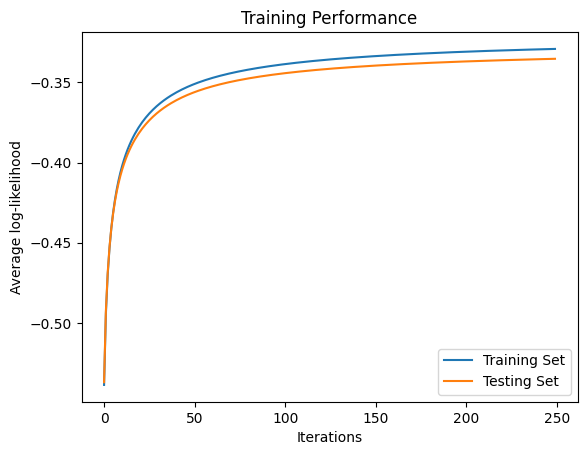

In [11]:
# Plot Log Likelihood values during training process
plot_log_likelihood_performance(learner.log_likelihood_train, learner.log_likelihood_test)

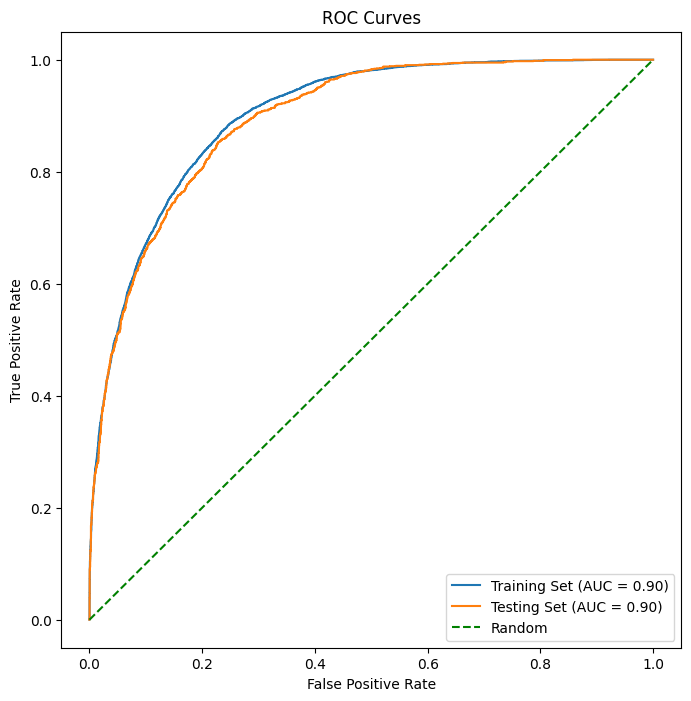

In [12]:
# Plot ROC curves
plot_roc(processed_X_train, y_train, processed_X_test, y_test, learner)